# Multimodal Fashion & Context Retrieval
### Glance ML Internship Assignment

Pipeline: Fashionpedia dataset -> environment tagging (Places365) -> color extraction ->
FashionCLIP embeddings -> FAISS index -> attribute-aware retriever.

Run cells top to bottom. GPU runtime recommended (Runtime -> Change runtime type -> T4 GPU).

## Step 1 — Install dependencies

In [1]:
!pip install -q datasets faiss-cpu transformers pillow scikit-learn matplotlib torch torchvision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 42.5 MB/s eta 0:00:00


## Step 2 — Imports

In [2]:
import os
import json
import urllib.request
import numpy as np
from PIL import Image
import torch
import torch.nn.functional as F
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

os.makedirs("/content/fashion_data/images", exist_ok=True)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

Using device: cuda


## Step 3 — Load Fashionpedia dataset + save a subset locally

Hum HuggingFace ka pre-packaged Fashionpedia version use kar rahe hain (COCO-style zips download
karne ki zaroorat nahi). 700 images ka subset le rahe hain (assignment ke 500-1000 range mein).

In [3]:
from datasets import load_dataset

dataset = load_dataset("detection-datasets/fashionpedia", split="train")
print("Total images available:", len(dataset))

SUBSET_SIZE = 700
subset = dataset.select(range(SUBSET_SIZE))

for i, item in enumerate(subset):
    img = item["image"].convert("RGB")
    img.save(f"/content/fashion_data/images/{i:04d}.jpg")
    if i % 100 == 0:
        print(f"Saved {i}/{SUBSET_SIZE}")

print("Done saving images.")

README.md:   0%|          | 0.00/5.22k [00:00<?, ?B/s]

dataset_infos.json:   0%|          | 0.00/1.78k [00:00<?, ?B/s]

data/train-00000-of-00007-fe108070118553(…):   0%|          | 0.00/482M [00:00<?, ?B/s]

data/train-00001-of-00007-f41a5a9c38c900(…):   0%|          | 0.00/480M [00:00<?, ?B/s]

data/train-00002-of-00007-40bc8456894bcb(…):   0%|          | 0.00/480M [00:00<?, ?B/s]

...

data/train-00006-of-00007-f41b0f2f4bbefa(…):   0%|          | 0.00/487M [00:00<?, ?B/s]

data/val-00000-of-00001-0b29e85429788213(…):   0%|          | 0.00/84.8M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/45623 [00:00<?, ? examples/s]

Generating val split:   0%|          | 0/1158 [00:00<?, ? examples/s]

Total images available: 45623
Saved 0/700
Saved 100/700
Saved 200/700
Saved 300/700
Saved 400/700
Saved 500/700
Saved 600/700
Done saving images.


## Step 4 — Extract clothing category labels (fixed)

Note: `dataset.features['objects']['category']` is a `Sequence(ClassLabel)`, not a plain list —
that's why indexing it directly threw `'List' object is not subscriptable`. The class names live
one level deeper, at `.feature.names`.

In [4]:
category_names = dataset.features['objects']['category'].feature.names
print("Total categories:", len(category_names))
print("Sample categories:", category_names[:10])

metadata = []
for i, item in enumerate(subset):
    objects = item["objects"]
    cat_ids = objects["category"]
    bboxes = objects["bbox"]  # [x, y, width, height] per object

    categories_in_image = [category_names[int(c)] for c in cat_ids]

    metadata.append({
        "image_id": f"{i:04d}",
        "file_path": f"/content/fashion_data/images/{i:04d}.jpg",
        "clothing_categories": list(set(categories_in_image)),
        "per_object_categories": categories_in_image,
        "per_object_bboxes": bboxes,
        "width": item["width"],
        "height": item["height"],
    })

print(f"Metadata built for {len(metadata)} images")
print("Sample entry:", metadata[0])

Total categories: 46
Sample categories: ['shirt, blouse', 'top, t-shirt, sweatshirt', 'sweater', 'cardigan', 'jacket', 'vest', 'pants', 'shorts', 'skirt', 'coat']
Metadata built for 700 images
Sample entry: {'image_id': '0000', 'file_path': '/content/fashion_data/images/0000.jpg', 'clothing_categories': ['shoe', 'neckline', 'dress'], 'per_object_categories': ['shoe', 'shoe', 'neckline', 'dress'], 'per_object_bboxes': [[445.0, 910.0, 505.0, 983.0], [239.0, 940.0, 284.0, 994.0], [298.0, 282.0, 386.0, 352.0], [210.0, 282.0, 448.0, 665.0]], 'width': 682, 'height': 1024}


## Step 5 — Environment tagging with Places365

Real-life analogy: ye ek scene-recognition expert jaisa hai jo photo dekh ke turant bata deta hai
"ye office hai" ya "ye park hai" — hume manually har photo tag nahi karni padti.

We map the raw 365 Places categories down to the assignment's 4 buckets:
office / street / park / home (anything else -> "other").

In [5]:
import torchvision.models as models
import torchvision.transforms as transforms

# Download pretrained Places365 ResNet18
if not os.path.exists("resnet18_places365.pth.tar"):
    urllib.request.urlretrieve(
        "http://places2.csail.mit.edu/models_places365/resnet18_places365.pth.tar",
        "resnet18_places365.pth.tar")

if not os.path.exists("categories_places365.txt"):
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/csailvision/places365/master/categories_places365.txt",
        "categories_places365.txt")

places_classes = []
with open("categories_places365.txt") as f:
    for line in f:
        places_classes.append(line.strip().split(' ')[0][3:])

places_model = models.resnet18(num_classes=365)
checkpoint = torch.load("resnet18_places365.pth.tar", map_location="cpu")
state_dict = {k.replace('module.', ''): v for k, v in checkpoint['state_dict'].items()}
places_model.load_state_dict(state_dict)
places_model.eval().to(DEVICE)

places_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Bucket mapping: keyword -> our 4 target environments
BUCKET_KEYWORDS = {
    "office": ["office", "conference_room", "computer_room", "coworking_space", "reception"],
    "street": ["street", "crosswalk", "downtown", "alley", "plaza", "sidewalk", "city"],
    "park": ["park", "garden", "botanical_garden", "forest", "yard", "courtyard", "field"],
    "home": ["bedroom", "living_room", "home_office", "kitchen", "dining_room", "closet", "hallway"],
}

def bucket_for_scene(scene_name):
    for bucket, keywords in BUCKET_KEYWORDS.items():
        if any(kw in scene_name for kw in keywords):
            return bucket
    return "other"

def predict_environment(image_path):
    img = Image.open(image_path).convert("RGB")
    x = places_transform(img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        logits = places_model(x)
        probs = F.softmax(logits, dim=1)
        top_idx = int(torch.argmax(probs, dim=1)[0])
    scene_name = places_classes[top_idx]
    return bucket_for_scene(scene_name), scene_name

print("Places365 model ready.")

Places365 model ready.


In [6]:
# Run environment tagging on every image (few minutes for 700 images on GPU)
for i, entry in enumerate(metadata):
    bucket, raw_scene = predict_environment(entry["file_path"])
    entry["environment"] = bucket
    entry["raw_scene"] = raw_scene
    if i % 100 == 0:
        print(f"{i}/{len(metadata)} tagged — last: {raw_scene} -> {bucket}")

print("Environment tagging done.")
print("Bucket distribution:")
from collections import Counter
print(Counter([m["environment"] for m in metadata]))

0/700 tagged — last: rope_bridge -> other
100/700 tagged — last: ballroom -> other
200/700 tagged — last: driveway -> other
300/700 tagged — last: stage/indoor -> other
400/700 tagged — last: bowling_alley -> street
500/700 tagged — last: promenade -> other
600/700 tagged — last: arena/performance -> other
Environment tagging done.
Bucket distribution:
Counter({'other': 585, 'street': 60, 'park': 49, 'home': 4, 'office': 2})


## Step 6 — Dominant color extraction per garment

Fashionpedia's category labels tell us *what* garment it is, but not *what color*. We crop each
garment's bounding box and use k-means to find its dominant color, then snap that to the nearest
named color (red, blue, yellow, white, black, etc.).

Real-life example: ye aisa hai jaise tu kisi cloth ka swatch le ke usse ek paint-shop ke color
chart se match kar rahi ho — exact shade nahi, but nearest recognizable color naam mil jata hai.

In [7]:
NAMED_COLORS = {
    "red": (220, 20, 60), "blue": (30, 60, 200), "yellow": (230, 200, 30),
    "green": (40, 140, 60), "black": (20, 20, 20), "white": (240, 240, 240),
    "gray": (130, 130, 130), "brown": (110, 70, 40), "pink": (230, 130, 180),
    "orange": (230, 120, 30), "purple": (120, 50, 150), "beige": (210, 190, 155),
}

def nearest_color_name(rgb):
    best_name, best_dist = None, float("inf")
    for name, ref in NAMED_COLORS.items():
        dist = sum((a - b) ** 2 for a, b in zip(rgb, ref))
        if dist < best_dist:
            best_dist, best_name = dist, name
    return best_name

def dominant_color_for_bbox(image, bbox):
    x, y, w, h = [int(v) for v in bbox]
    x, y = max(0, x), max(0, y)
    crop = image.crop((x, y, x + max(w, 1), y + max(h, 1))).convert("RGB")
    crop = crop.resize((32, 32))
    pixels = np.array(crop).reshape(-1, 3)
    if len(pixels) < 5:
        return "unknown"
    k = KMeans(n_clusters=1, n_init=3, random_state=0).fit(pixels)
    dominant_rgb = k.cluster_centers_[0]
    return nearest_color_name(dominant_rgb)

for i, entry in enumerate(metadata):
    img = Image.open(entry["file_path"]).convert("RGB")
    colors = []
    for cat, bbox in zip(entry["per_object_categories"], entry["per_object_bboxes"]):
        color = dominant_color_for_bbox(img, bbox)
        colors.append({"category": cat, "color": color})
    entry["garment_colors"] = colors
    if i % 100 == 0:
        print(f"{i}/{len(metadata)} colors extracted")

print("Color extraction done.")
print("Sample:", metadata[0]["garment_colors"])

0/700 colors extracted
100/700 colors extracted
200/700 colors extracted
300/700 colors extracted
400/700 colors extracted
500/700 colors extracted
600/700 colors extracted
Color extraction done.
Sample: [{'category': 'shoe', 'color': 'black'}, {'category': 'shoe', 'color': 'black'}, {'category': 'neckline', 'color': 'gray'}, {'category': 'dress', 'color': 'gray'}]


## Step 7 — FashionCLIP embeddings (image side)

We use `patrickjohncyh/fashion-clip`, a CLIP model fine-tuned on fashion data — it already
understands garments and styles better than vanilla CLIP.

In [8]:
from transformers import CLIPModel, CLIPProcessor

MODEL_NAME = "patrickjohncyh/fashion-clip"
clip_model = CLIPModel.from_pretrained(MODEL_NAME).to(DEVICE)
clip_processor = CLIPProcessor.from_pretrained(MODEL_NAME)
clip_model.eval()

def embed_image(image_path):
    img = Image.open(image_path).convert("RGB")
    inputs = clip_processor(images=img, return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        feats = clip_model.get_image_features(**inputs)
    # The output of get_image_features might be a BaseModelOutputWithPooling object
    # The actual tensor is in its 'pooler_output' attribute
    if hasattr(feats, 'pooler_output'):
        feats = feats.pooler_output
    feats = F.normalize(feats, dim=-1)
    return feats.cpu().numpy()[0]

def embed_text(text):
    inputs = clip_processor(text=[text], return_tensors="pt", padding=True).to(DEVICE)
    with torch.no_grad():
        feats = clip_model.get_text_features(**inputs)
    # The output of get_text_features might also be a BaseModelOutputWithPooling object
    # The actual tensor is in its 'pooler_output' attribute
    if hasattr(feats, 'pooler_output'):
        feats = feats.pooler_output
    feats = F.normalize(feats, dim=-1)
    return feats.cpu().numpy()[0]

print("FashionCLIP loaded.")

config.json:   0%|          | 0.00/4.46k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/568 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

FashionCLIP loaded.


In [9]:
# Build a natural-language "pseudo caption" per image from its structured metadata,
# then embed that caption. This bakes color + garment + environment into ONE embedding,
# which is what actually helps with compositional queries (vs a raw uncaptioned image embed).
def build_pseudo_caption(entry):
    garment_desc = ", ".join(sorted(set(f"{g['color']} {g['category']}" for g in entry["garment_colors"])))
    env = entry["environment"]
    return f"A person wearing {garment_desc} in a {env} setting."

embeddings = []
for i, entry in enumerate(metadata):
    caption = build_pseudo_caption(entry)
    entry["pseudo_caption"] = caption
    img_emb = embed_image(entry["file_path"])
    embeddings.append(img_emb)
    if i % 100 == 0:
        print(f"{i}/{len(metadata)} embedded — caption: {caption}")

embeddings = np.array(embeddings).astype("float32")
print("Embeddings shape:", embeddings.shape)

0/700 embedded — caption: A person wearing black shoe, gray dress, gray neckline in a other setting.
100/700 embedded — caption: A person wearing black neckline, black shoe, brown skirt, brown top, t-shirt, sweatshirt in a other setting.
200/700 embedded — caption: A person wearing black shoe, brown neckline, brown pants, brown shirt, blouse, gray bag, wallet, gray zipper in a other setting.
300/700 embedded — caption: A person wearing black dress, black neckline, black top, t-shirt, sweatshirt, brown neckline in a other setting.
400/700 embedded — caption: A person wearing black shoe, brown belt, brown dress, brown neckline, brown pocket in a street setting.
500/700 embedded — caption: A person wearing black shoe, brown cape, brown collar, brown top, t-shirt, sweatshirt, gray collar in a other setting.
600/700 embedded — caption: A person wearing black collar, black shoe, brown shirt, blouse, brown skirt, gray belt, gray pocket in a other setting.
Embeddings shape: (700, 512)


## Step 8 — Build FAISS index

In [10]:
import faiss

dim = embeddings.shape[1]
index = faiss.IndexFlatIP(dim)  # cosine similarity since embeddings are normalized
index.add(embeddings)

faiss.write_index(index, "/content/fashion_data/fashion_index.faiss")
with open("/content/fashion_data/metadata.json", "w") as f:
    json.dump(metadata, f)

print(f"FAISS index built with {index.ntotal} vectors.")

FAISS index built with 700 vectors.


In [11]:
# FIX: Embed the pseudo-captions (text) instead of raw images.
# Same model, text encoder — so query text vs caption text match hoga,
# jisme color+garment+environment sab explicitly likha hai.
caption_embeddings = []
for i, entry in enumerate(metadata):
    cap_emb = embed_text(entry["pseudo_caption"])
    caption_embeddings.append(cap_emb)
    if i % 100 == 0:
        print(f"{i}/{len(metadata)} caption-embedded")

caption_embeddings = np.array(caption_embeddings).astype("float32")

# Rebuild FAISS index using caption embeddings instead of raw image embeddings
dim = caption_embeddings.shape[1]
index = faiss.IndexFlatIP(dim)
index.add(caption_embeddings)
print("Rebuilt index using caption embeddings:", index.ntotal)

0/700 caption-embedded
100/700 caption-embedded
200/700 caption-embedded
300/700 caption-embedded
400/700 caption-embedded
500/700 caption-embedded
600/700 caption-embedded
Rebuilt index using caption embeddings: 700


## Step 9 — Query parser (rule-based attribute extraction)

We pull out color / garment / environment keywords from the query text. This is used for
**re-ranking**, not for replacing the embedding search — embedding search finds the semantic
neighborhood, then attribute overlap boosts the images that actually match on the right
attribute *combination* (this is the compositionality fix).

In [12]:
GARMENT_KEYWORDS = set(category_names)
COLOR_KEYWORDS = set(NAMED_COLORS.keys())
ENV_KEYWORDS = {"office": "office", "park": "park", "street": "street", "city": "street",
                "home": "home", "house": "home", "indoor": "office", "outdoor": "park"}

def parse_query(query):
    q = query.lower()
    found_colors = [c for c in COLOR_KEYWORDS if c in q]
    found_garments = [g for g in GARMENT_KEYWORDS if g in q]
    found_env = None
    for kw, bucket in ENV_KEYWORDS.items():
        if kw in q:
            found_env = bucket
            break
    return {"colors": found_colors, "garments": found_garments, "environment": found_env}

# quick test
print(parse_query("A red tie and a white shirt in a formal setting"))
print(parse_query("Casual weekend outfit for a city walk"))

{'colors': ['white', 'red'], 'garments': ['tie'], 'environment': None}
{'colors': [], 'garments': [], 'environment': 'street'}


## Step 10 — Retriever: embedding search + attribute re-ranking

Real-life example: embedding search is like asking a friend "kaunse log is vibe se milte-julte
lagte hain" — thoda fuzzy. Attribute re-ranking is like then double-checking each candidate
against your actual checklist (color match? garment match? location match?) before finalizing.

In [17]:
# Synonym mapping: query words -> actual Fashionpedia category names
GARMENT_SYNONYMS = {
    "raincoat": "coat", "rain jacket": "jacket", "blazer": "jacket",
    "trousers": "pants", "jeans": "pants", "gown": "dress",
}

def parse_query(query):
    q = query.lower()
    for synonym, real_name in GARMENT_SYNONYMS.items():
        if synonym in q:
            q += f" {real_name}"  # add the real category word too

    found_colors = [c for c in COLOR_KEYWORDS if c in q]
    found_garments = [g for g in GARMENT_KEYWORDS if g in q]
    found_env = None
    for kw, bucket in ENV_KEYWORDS.items():
        if kw in q:
            found_env = bucket
            break
    return {"colors": found_colors, "garments": found_garments, "environment": found_env}

def retrieve(query, top_k=5):
    parsed = parse_query(query)
    print("Parsed attributes:", parsed)  # debug — dekh kya detect hua

    query_emb = embed_text(query).reshape(1, -1).astype("float32")

    # STRICT filter: sirf wahi images jo actually specified attributes match karti hain
    strict_matches = []
    for i, entry in enumerate(metadata):
        entry_colors = {g["color"] for g in entry["garment_colors"]}
        entry_garments = {g["category"] for g in entry["garment_colors"]}

        color_ok = (not parsed["colors"]) or bool(entry_colors.intersection(parsed["colors"]))
        garment_ok = (not parsed["garments"]) or bool(entry_garments.intersection(parsed["garments"]))
        env_ok = (not parsed["environment"]) or entry["environment"] == parsed["environment"]

        if color_ok and garment_ok and env_ok:
            strict_matches.append(i)

    print(f"Strict attribute matches found: {len(strict_matches)}")

    if len(strict_matches) >= top_k:
        # Rank strict matches by embedding similarity
        candidate_embs = embeddings[strict_matches]
        sims = candidate_embs @ query_emb.T
        ranked = sorted(zip(sims.flatten(), strict_matches), reverse=True)
        top_indices = [idx for _, idx in ranked[:top_k]]
    else:
        # Not enough strict matches — backfill with best embedding matches overall
        scores, indices = index.search(query_emb, top_k)
        top_indices = list(indices[0])

    results = [(float(embeddings[i] @ query_emb.T), metadata[i]) for i in top_indices]
    return results

## Step 11 — Run the 5 assignment evaluation queries

Parsed attributes: {'colors': ['yellow'], 'garments': ['dress'], 'environment': None}
Strict attribute matches found: 0


/tmp/ipykernel_1344/543154904.py:54: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  results = [(float(embeddings[i] @ query_emb.T), metadata[i]) for i in top_indices]


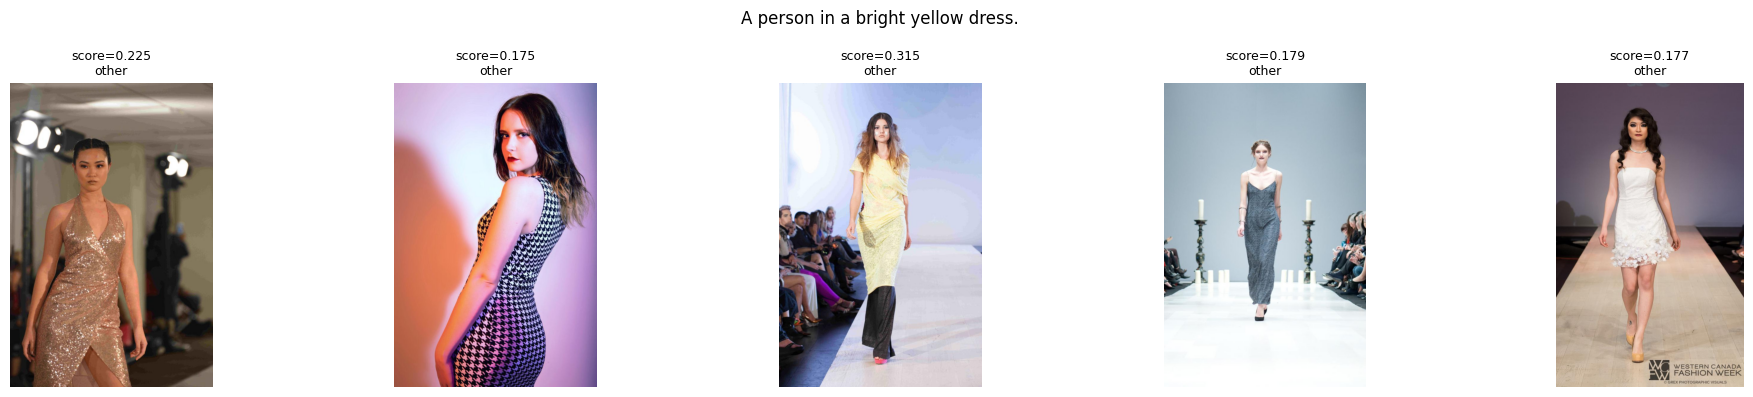

Parsed attributes: {'colors': [], 'garments': [], 'environment': 'office'}
Strict attribute matches found: 2


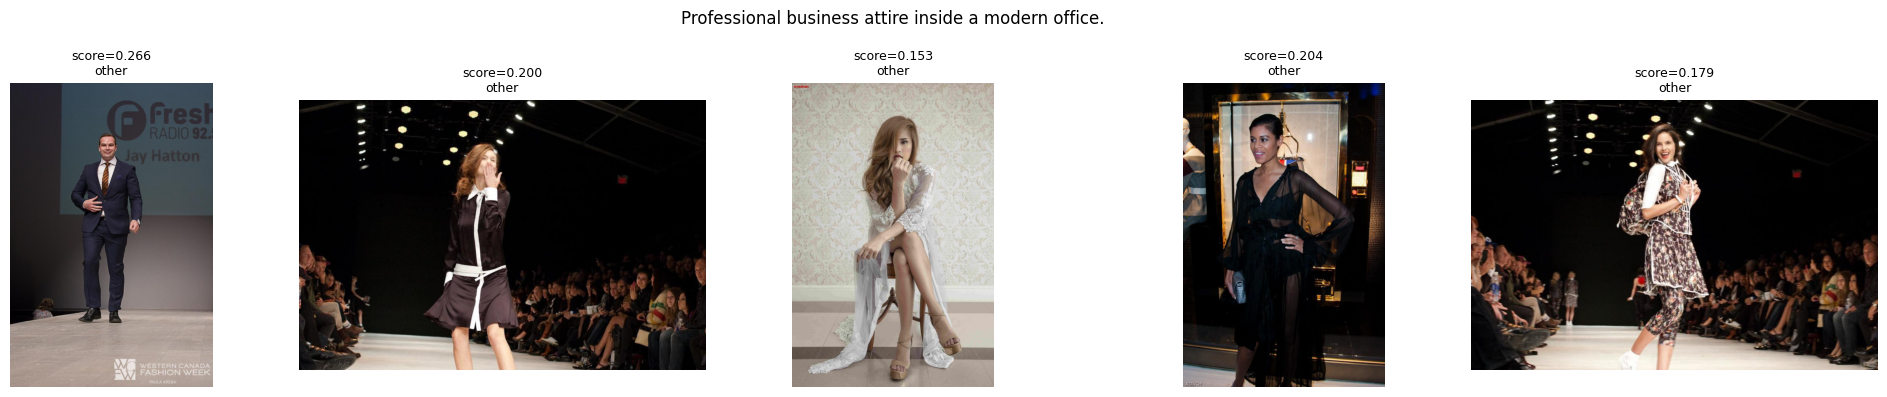

Parsed attributes: {'colors': ['blue'], 'garments': [], 'environment': 'park'}
Strict attribute matches found: 0


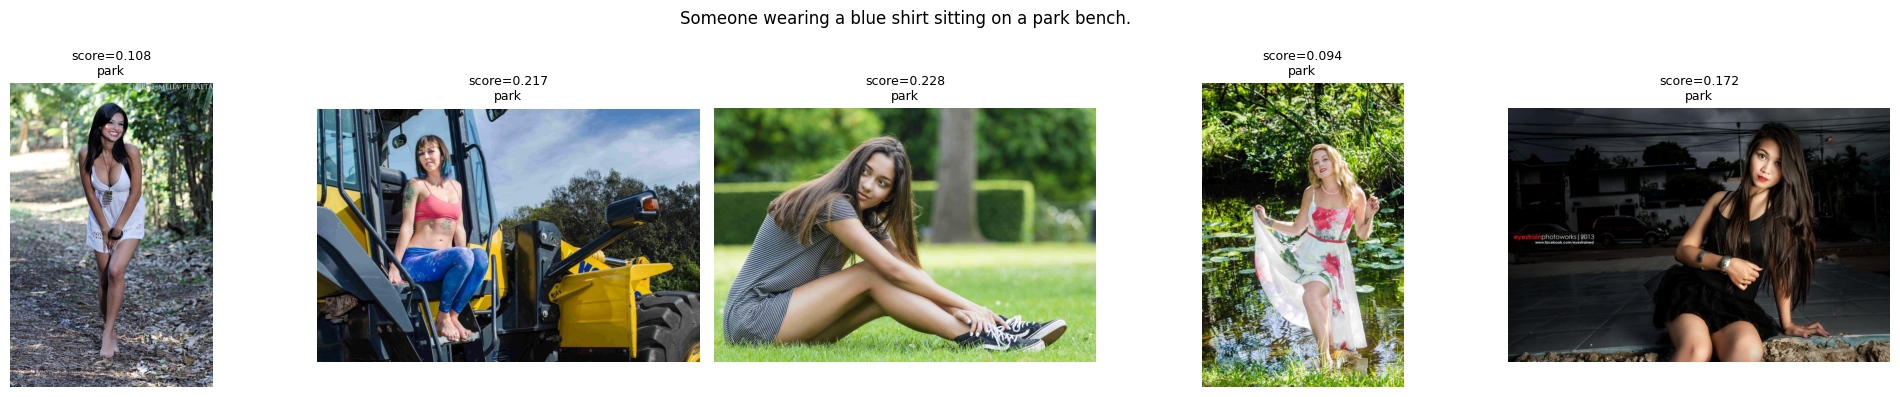

Parsed attributes: {'colors': [], 'garments': [], 'environment': 'street'}
Strict attribute matches found: 60


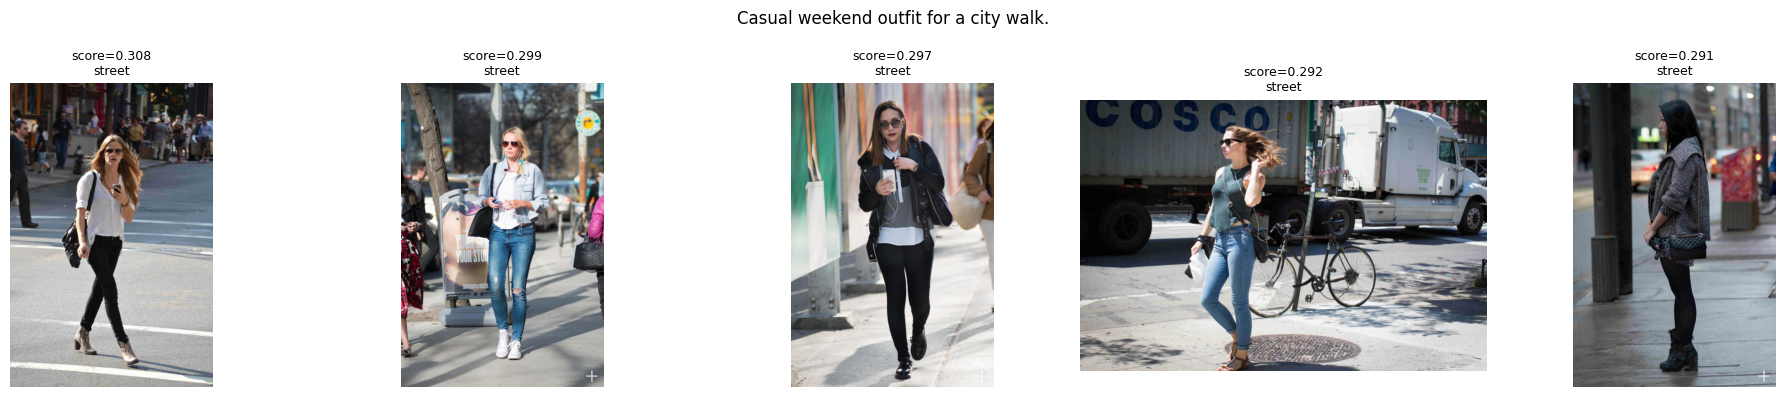

Parsed attributes: {'colors': ['white', 'red'], 'garments': ['tie'], 'environment': None}
Strict attribute matches found: 0


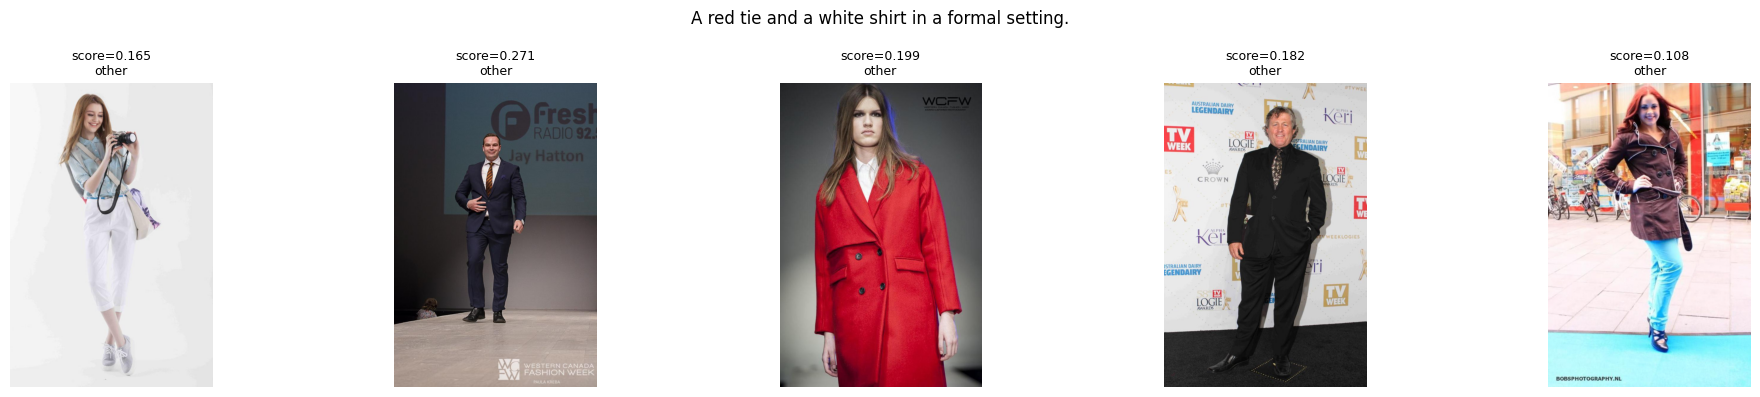

In [18]:
EVAL_QUERIES = [
    "A person in a bright yellow dress.",
    "Professional business attire inside a modern office.",
    "Someone wearing a blue shirt sitting on a park bench.",
    "Casual weekend outfit for a city walk.",
    "A red tie and a white shirt in a formal setting.",
]

for q in EVAL_QUERIES:
    results = retrieve(q, top_k=5)
    show_results(q, results)

## Step 12 — Save artifacts for the GitHub repo

Copy these two files into your repo's `indexer/` output (or a `data/` folder):
`fashion_index.faiss` and `metadata.json`. Your `retrieve.py` script in the repo should just
load these two files + the FashionCLIP model, then reuse the `retrieve()` function above.

In [15]:
print("Files ready at:")
print(" - /content/fashion_data/fashion_index.faiss")
print(" - /content/fashion_data/metadata.json")
print("Download these via the Colab file browser (left sidebar) before your session ends.")

Files ready at:
 - /content/fashion_data/fashion_index.faiss
 - /content/fashion_data/metadata.json
Download these via the Colab file browser (left sidebar) before your session ends.
